In [11]:
import pandas as pd
print(pd.__version__)

2.2.2


In [13]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [14]:
df.shape

(7043, 33)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [16]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [52]:
df.columns
# Listar colunas e seus tipos de dados
for col in df.columns:
    print(col, "->", df[col].dtype)

CustomerID -> object
Count -> int64
Country -> object
State -> object
City -> object
Zip Code -> int64
Lat Long -> object
Latitude -> float64
Longitude -> float64
Gender -> object
Senior Citizen -> object
Partner -> object
Dependents -> object
Tenure Months -> int64
Phone Service -> object
Multiple Lines -> object
Internet Service -> object
Online Security -> object
Online Backup -> object
Device Protection -> object
Tech Support -> object
Streaming TV -> object
Streaming Movies -> object
Contract -> object
Paperless Billing -> object
Payment Method -> object
Monthly Charges -> float64
Total Charges -> object
Churn Label -> object
Churn Value -> int64
Churn Score -> int64
CLTV -> int64
Churn Reason -> object


In [26]:
df[['Churn Label', 'Churn Value', 'Churn Score', 'Churn Reason']]

,Churn Label,Churn Value,Churn Score,Churn Reason
0,Yes,1,86,Competitor made better offer
1,Yes,1,67,Moved
2,Yes,1,86,Moved
3,Yes,1,84,Moved
4,Yes,1,89,Competitor had better devices
...,...,...,...,...
7038,No,0,45,NaN
7039,No,0,59,NaN
7040,No,0,71,NaN
7041,No,0,59,NaN


In [29]:
df['Churn Value'].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [38]:
df['Churn Value'].mean().round(3) * 100

np.float64(26.5)

In [43]:
total_clientes = df.shape[0]
cancelamentos = df['Churn Value'].sum()
taxa_churn = df['Churn Value'].mean()

print("Total de clientes:", total_clientes)
print("Clientes que cancelaram:", cancelamentos)
print("Taxa de churn:", round(taxa_churn*100,2), "%")

Total de clientes: 7043
Clientes que cancelaram: 1869
Taxa de churn: 26.54 %


In [44]:
df.groupby('Contract')['Churn Value'].mean().sort_values(ascending=False).round(3)

Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn Value, dtype: float64

Clientes com contrato mensal apresentam risco de churn significativamente maior. Estratégias de retenção deveriam priorizar a conversão desses clientes para contratos anuais.

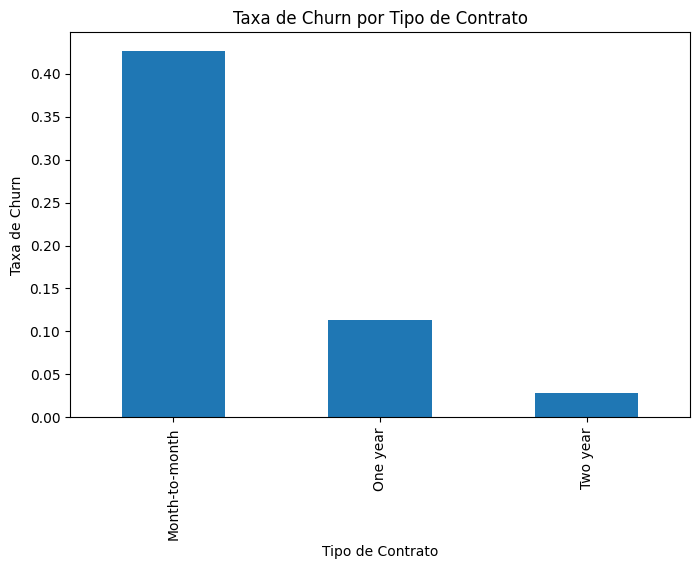

In [48]:
import matplotlib.pyplot as plt
churn_contract = df.groupby('Contract')['Churn Value'].mean()

plt.figure(figsize=(8,5))
churn_contract.plot(kind='bar')

plt.title('Taxa de Churn por Tipo de Contrato')
plt.ylabel('Taxa de Churn')
plt.xlabel('Tipo de Contrato')

plt.show()

### Insight 1 — Contrato influencia fortemente o churn

A taxa de churn varia significativamente conforme o tipo de contrato:

- Month-to-month: ~42.7%
- One year: ~11.3%
- Two year: ~2.8%

Clientes com contrato mensal apresentam risco de cancelamento muito maior.
Isso sugere que estratégias de retenção deveriam priorizar a conversão
desses clientes para contratos de maior duração.

In [55]:
# Substituir espaços vazios por NaN e converter para float
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# Verificar valores nulos gerados
df["Total Charges"].isna().sum()

np.int64(11)

In [56]:
# Correlação de Pearson

cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Churn Value']
df[cols].corr()

,Tenure Months,Monthly Charges,Total Charges,CLTV,Churn Value
Tenure Months,1.000000,0.247900,0.825880,0.396406,-0.352229
Monthly Charges,0.247900,1.000000,0.651065,0.098693,0.193356
Total Charges,0.825880,0.651065,1.000000,0.341837,-0.199484
CLTV,0.396406,0.098693,0.341837,1.000000,-0.127463
Churn Value,-0.352229,0.193356,-0.199484,-0.127463,1.000000


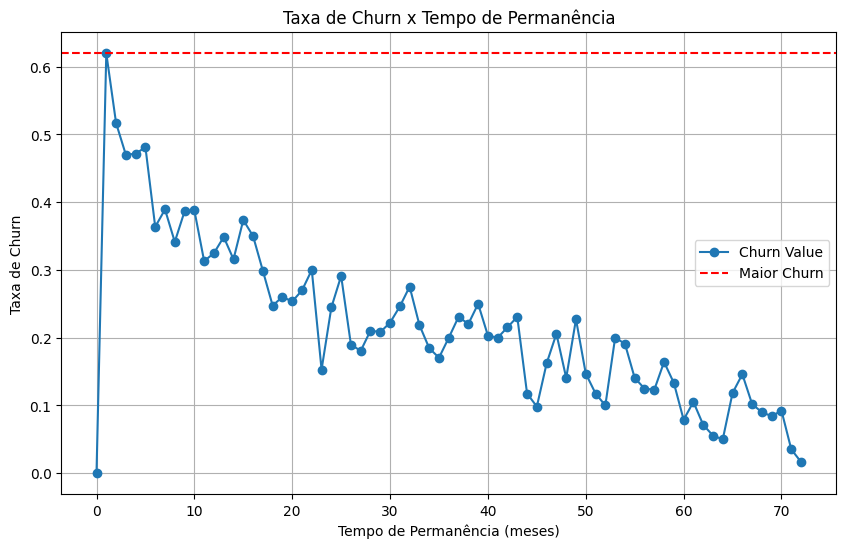

In [58]:
import matplotlib.pyplot as plt

#Agrupar churn por tempo de permanência
tenure_churn = df.groupby('Tenure Months')['Churn Value'].mean()

plt.figure(figsize=(10,6))
tenure_churn.plot(kind='line', marker='o')
plt.title('Taxa de Churn x Tempo de Permanência')
plt.ylabel('Taxa de Churn')
plt.xlabel('Tempo de Permanência (meses)')
plt.grid(True)

# opcional: destacar clientes com maior churn
plt.axhline(y=tenure_churn.max(), color='red', linestyle='--', label="Maior Churn")
plt.legend()

plt.show()

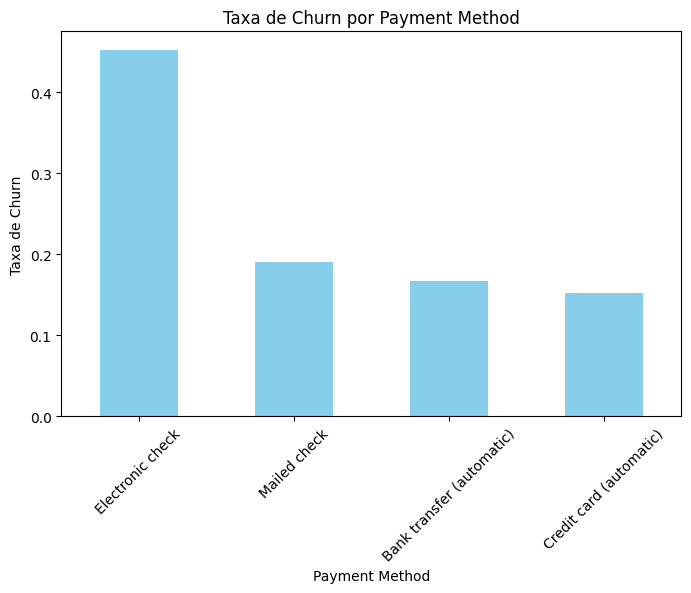

Payment Method
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn Value, dtype: float64

In [59]:
def plot_churn_by_category(col):
    """
    Calcula e plota a taxa de churn para cada categoria de uma coluna.
    """
    churn_cat = df.groupby(col)["Churn Value"].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(8,5))
    churn_cat.plot(kind="bar", color="skyblue")
    
    plt.title(f"Taxa de Churn por {col}")
    plt.ylabel("Taxa de Churn")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.show()
    
    return churn_cat

# Exemplo de uso
plot_churn_by_category("Payment Method")


--- Taxa de Churn por Contract ---


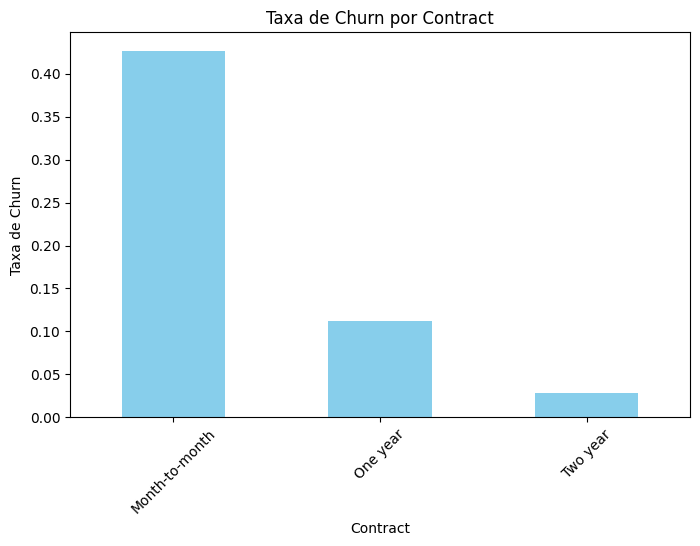

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn Value, dtype: float64

--- Taxa de Churn por Internet Service ---


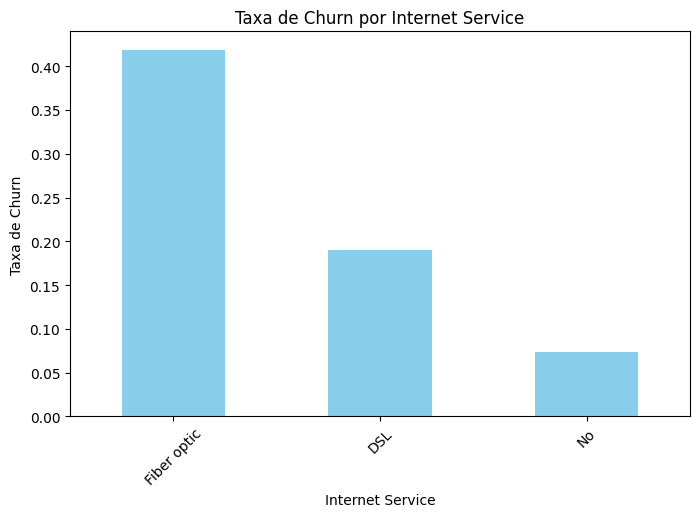

Internet Service
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn Value, dtype: float64

--- Taxa de Churn por Tech Support ---


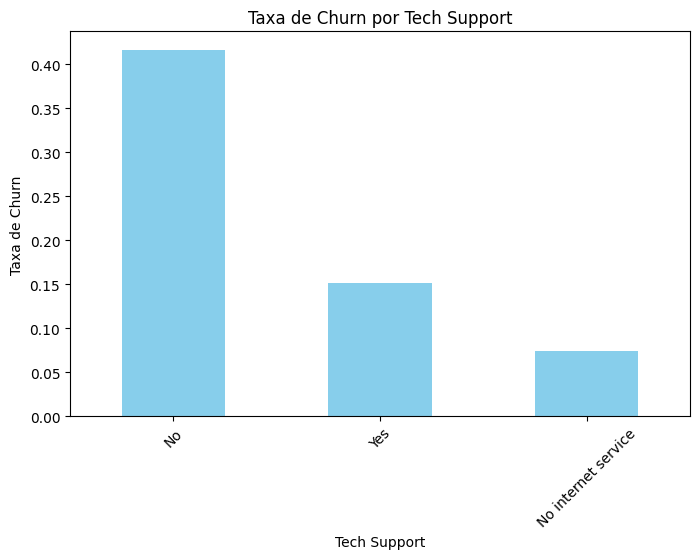

Tech Support
No                     0.416355
Yes                    0.151663
No internet service    0.074050
Name: Churn Value, dtype: float64

--- Taxa de Churn por Paperless Billing ---


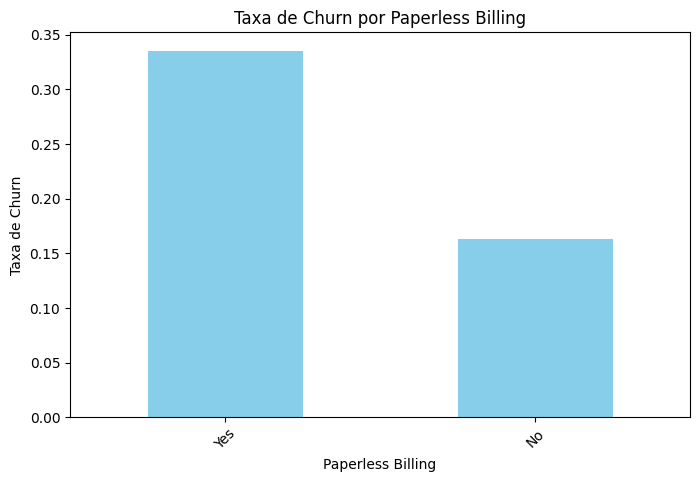

Paperless Billing
Yes    0.335651
No     0.163301
Name: Churn Value, dtype: float64

--- Taxa de Churn por Streaming TV ---


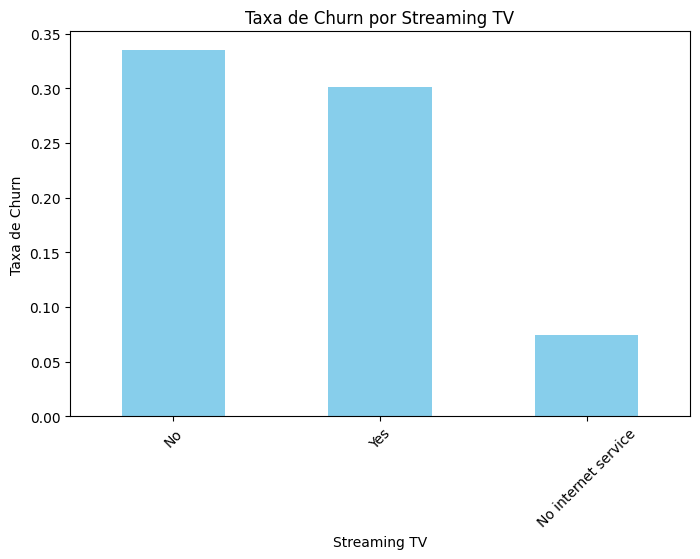

Streaming TV
No                     0.335231
Yes                    0.300702
No internet service    0.074050
Name: Churn Value, dtype: float64

--- Taxa de Churn por Streaming Movies ---


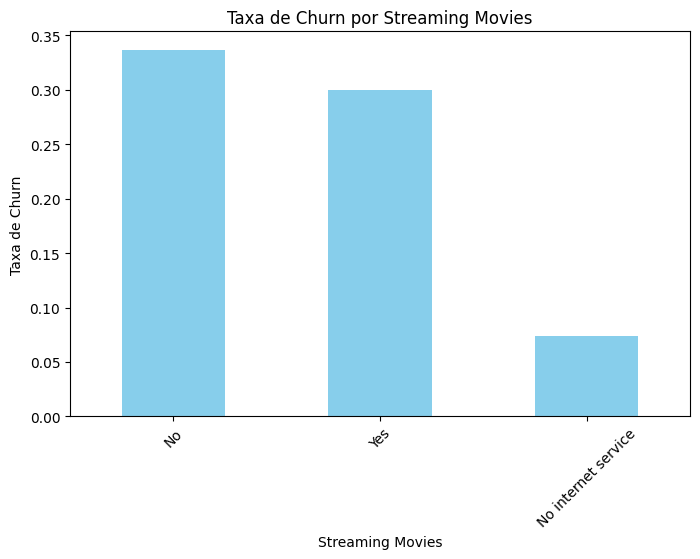

Streaming Movies
No                     0.336804
Yes                    0.299414
No internet service    0.074050
Name: Churn Value, dtype: float64


In [61]:
# Lista de colunas categóricas relevantes
categorical_cols = [
    "Contract",
    "Internet Service",
    "Tech Support",
    "Paperless Billing",
    "Streaming TV",
    "Streaming Movies"
]

# Loop para gerar gráficos e taxas
for col in categorical_cols:
    print(f"\n--- Taxa de Churn por {col} ---")
    churn_rates = plot_churn_by_category(col)
    print(churn_rates)

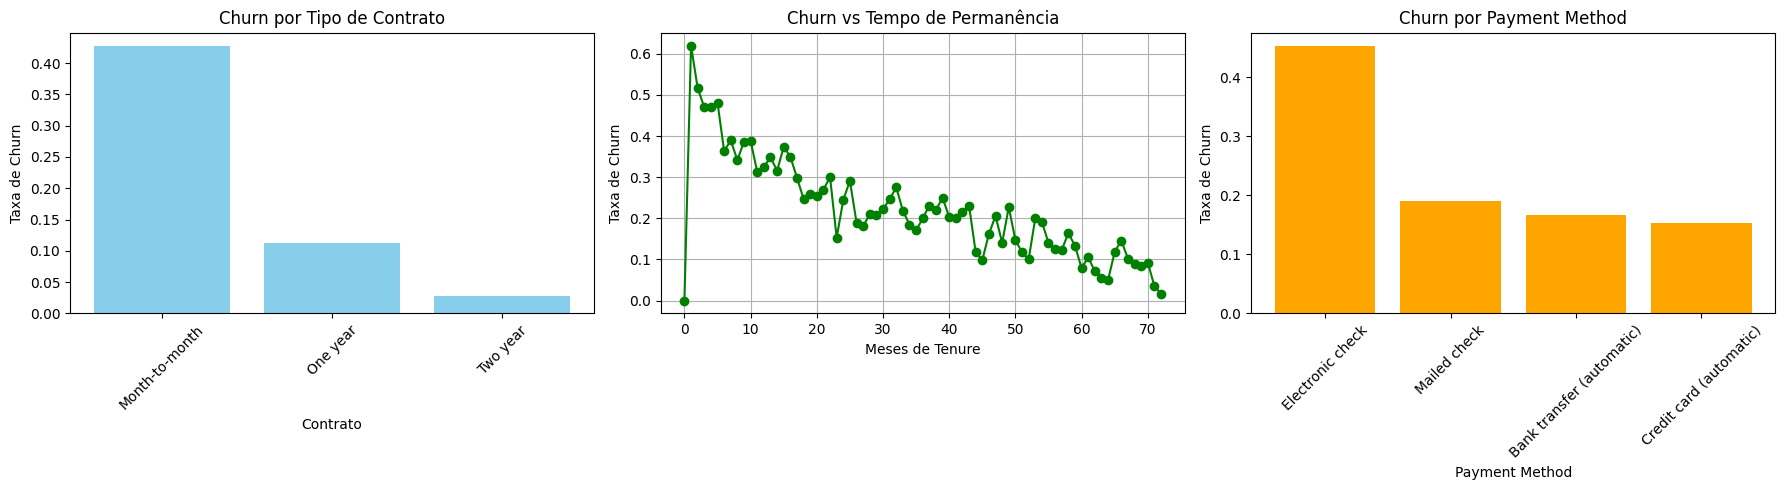

In [62]:
import matplotlib.pyplot as plt

# Criar figura com 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 1. Churn por tipo de contrato
churn_contract = df.groupby("Contract")["Churn Value"].mean().sort_values(ascending=False)
axes[0].bar(churn_contract.index, churn_contract.values, color="skyblue")
axes[0].set_title("Churn por Tipo de Contrato")
axes[0].set_ylabel("Taxa de Churn")
axes[0].set_xlabel("Contrato")
axes[0].tick_params(axis='x', rotation=45)

# 2. Churn por tempo de permanência (Tenure Months)
tenure_churn = df.groupby("Tenure Months")["Churn Value"].mean()
axes[1].plot(tenure_churn.index, tenure_churn.values, marker='o', color="green")
axes[1].set_title("Churn vs Tempo de Permanência")
axes[1].set_ylabel("Taxa de Churn")
axes[1].set_xlabel("Meses de Tenure")
axes[1].grid(True)

# 3. Churn por método de pagamento
churn_payment = df.groupby("Payment Method")["Churn Value"].mean().sort_values(ascending=False)
axes[2].bar(churn_payment.index, churn_payment.values, color="orange")
axes[2].set_title("Churn por Payment Method")
axes[2].set_ylabel("Taxa de Churn")
axes[2].set_xlabel("Payment Method")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

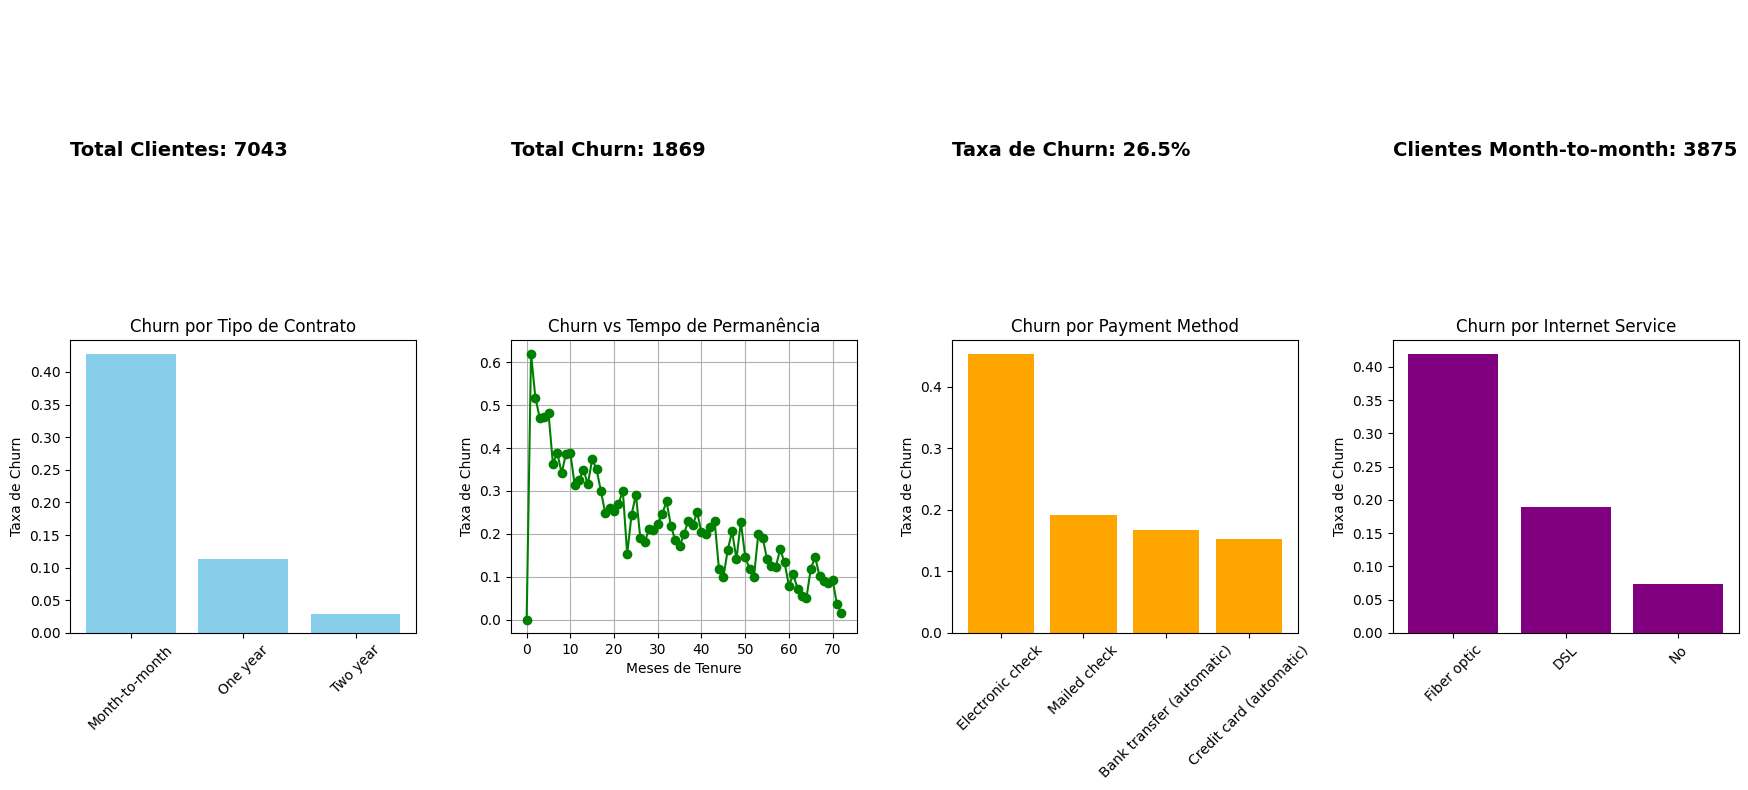

In [63]:
# Calcular KPIs
total_clientes = df.shape[0]
total_churn = df["Churn Value"].sum()
taxa_churn = df["Churn Value"].mean()*100
clientes_mes_to_mes = df[df["Contract"]=="Month-to-month"].shape[0]

# Criar figura grande
fig = plt.figure(figsize=(18,8))

# KPIs no topo
plt.subplot2grid((2,4), (0,0))
plt.axis('off')
plt.text(0,0.5,f"Total Clientes: {total_clientes}", fontsize=14, fontweight='bold')

plt.subplot2grid((2,4), (0,1))
plt.axis('off')
plt.text(0,0.5,f"Total Churn: {total_churn}", fontsize=14, fontweight='bold')

plt.subplot2grid((2,4), (0,2))
plt.axis('off')
plt.text(0,0.5,f"Taxa de Churn: {taxa_churn:.1f}%", fontsize=14, fontweight='bold')

plt.subplot2grid((2,4), (0,3))
plt.axis('off')
plt.text(0,0.5,f"Clientes Month-to-month: {clientes_mes_to_mes}", fontsize=14, fontweight='bold')

# Gráfico 1: Churn por contrato
plt.subplot2grid((2,4), (1,0))
churn_contract = df.groupby("Contract")["Churn Value"].mean().sort_values(ascending=False)
plt.bar(churn_contract.index, churn_contract.values, color="skyblue")
plt.title("Churn por Tipo de Contrato")
plt.ylabel("Taxa de Churn")
plt.xticks(rotation=45)

# Gráfico 2: Churn vs Tenure
plt.subplot2grid((2,4), (1,1))
tenure_churn = df.groupby("Tenure Months")["Churn Value"].mean()
plt.plot(tenure_churn.index, tenure_churn.values, marker='o', color="green")
plt.title("Churn vs Tempo de Permanência")
plt.ylabel("Taxa de Churn")
plt.xlabel("Meses de Tenure")
plt.grid(True)

# Gráfico 3: Churn por Payment Method
plt.subplot2grid((2,4), (1,2))
churn_payment = df.groupby("Payment Method")["Churn Value"].mean().sort_values(ascending=False)
plt.bar(churn_payment.index, churn_payment.values, color="orange")
plt.title("Churn por Payment Method")
plt.ylabel("Taxa de Churn")
plt.xticks(rotation=45)

# Gráfico 4: Churn por Internet Service
plt.subplot2grid((2,4), (1,3))
churn_internet = df.groupby("Internet Service")["Churn Value"].mean().sort_values(ascending=False)
plt.bar(churn_internet.index, churn_internet.values, color="purple")
plt.title("Churn por Internet Service")
plt.ylabel("Taxa de Churn")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()